In [1]:
from miss_alignment.data.io import read_tomogram_from_pickle
from copy import deepcopy
import torch
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
from utils import read_aretomo_alignment, center_tomogram

In [2]:
sns.set(style='darkgrid', context='talk')

In [3]:
TOMO_SHAPE = (128, 256, 256)

results = []
i = 5
experiments = [
    'run_ablation_reference',
    'run_ablation1',
    'run_ablation2',
    'run_ablation3',
    'run_ablation4',
]
for experiment in experiments:
    for x in range(10):
        gt = read_tomogram_from_pickle(f'/data/mchaillet/model_training/shrec/run8/ground_truth/model_{x}.pickle')
        tomo = read_tomogram_from_pickle(f'/data/mchaillet/model_training/shrec/{experiment}/iter{i}/model_{x}.pickle')
        abs_diff = torch.abs(gt.sample_translations - tomo.sample_translations)
        for a in abs_diff:
            results.append([experiment, x, a[0].item(), a[1].item()])


for x in range(10):
    gt = read_tomogram_from_pickle(f'/data/mchaillet/model_training/shrec/run8/ground_truth/model_{x}.pickle')
    at_alignment = read_aretomo_alignment(f'aretomo1_alignment/model_{x}.aln')
    at = deepcopy(gt)
    at.sample_translations = at_alignment
    # at = center_tomogram(gt, at, TOMO_SHAPE)
    abs_diff = torch.abs(gt.sample_translations - at.sample_translations)
    for a in abs_diff:
            results.append(['aretomo', x, a[0].item(), a[1].item()])
        

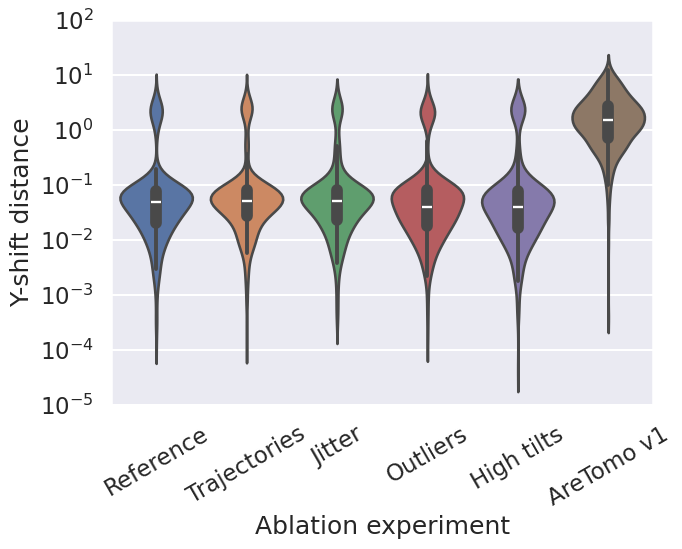

In [11]:
data = pd.DataFrame(results, columns=['experiment', 'model', 'abs y diff', 'abs x diff'])

fig, ax = plt.subplots(figsize=(7 * (len(experiments) / 5),5))
sns.violinplot(data=data, x='experiment', y='abs y diff', hue='experiment', legend=False, log_scale=True, ax=ax)
ax.set_yscale('log')
ax.set_ylabel('Y-shift distance')
xticks = ax.get_xticks()
ax.set_xticks(xticks, ['Reference', 'Trajectories', 'Jitter', 'Outliers', 'High tilts', 'AreTomo v1'], rotation=30)
ax.set_xlabel('Ablation experiment')
ax.set_ylim(1e-5, 100)
plt.savefig(f'ablation_violin_abs_y_diff.png', dpi=300, bbox_inches='tight')

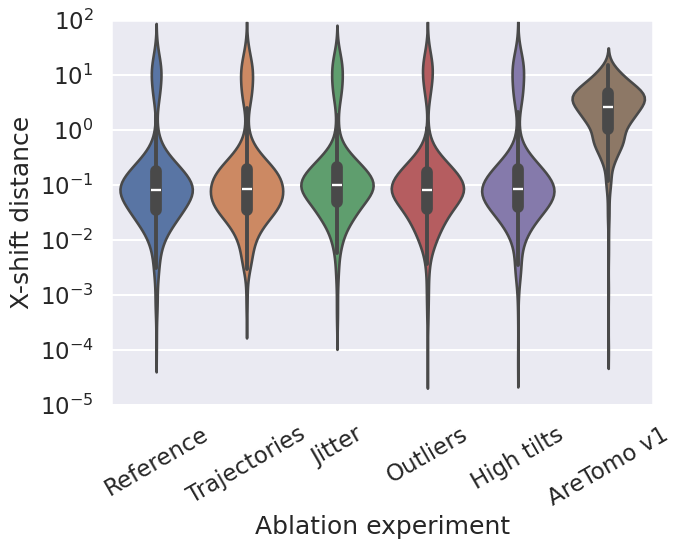

In [12]:
fig, ax = plt.subplots(figsize=(7 * (len(experiments) / 5),5))
sns.violinplot(data=data, x='experiment', y='abs x diff', hue='experiment', legend=False, log_scale=True, ax=ax)
ax.set_yscale('log')
ax.set_ylabel('X-shift distance')
xticks = ax.get_xticks()
ax.set_xticks(xticks, ['Reference', 'Trajectories', 'Jitter', 'Outliers', 'High tilts', 'AreTomo v1'], rotation=30)
ax.set_xlabel('Ablation experiment')
ax.set_ylim(1e-5, 100)
plt.savefig(f'ablation_violin_abs_x_diff.png', dpi=300, bbox_inches='tight')